In [2]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import zipfile

In [12]:
transform = transforms.ToTensor()

with zipfile.ZipFile("C:\\Users\\Marien\\Downloads\\archive.zip", "r") as zip_ref:
    zip_ref.extractall("cats")

dataset = torchvision.datasets.ImageFolder(root="cats", transform=transform)

data_loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [20]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.generator = nn.Sequential(
            nn.Linear(100, 512 * 4 * 4),
            nn.ReLU(),
            nn.Unflatten(1, (512, 4, 4)),
            nn.BatchNorm2d(512),

            nn.ConvTranspose2d(512, 256, 3, 2, 1, 1), #8
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 3, 2, 1, 1), #16
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 32, 3, 2, 1, 1), #32
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, 3, 2, 1, 1), #64
            nn.Sigmoid()
            )

    def forward(self, x):
        x = self.generator(x)
        return x


class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.discriminator = nn.Sequential(
            nn.Conv2d(3, 32, 3, 2, 1), #32
            nn.LeakyReLU(0.05),

            nn.Conv2d(32, 128, 3, 2, 1),
            nn.LeakyReLU(0.05),
        
            nn.Conv2d(128, 256, 3, 2, 1),
            nn.LeakyReLU(0.05),
        
            nn.Conv2d(256, 512, 3, 2, 1),
            nn.LeakyReLU(0.05),
        
            nn.Flatten(),
            nn.Linear(8192, 1)        
                )
    def forward(self, x):
        return self.discriminator(x)



In [21]:
dis = Discriminator()
gen = Generator()
optimizer1 = optim.Adam(dis.parameters(), lr = 0.001)
optimizer2 = optim.Adam(gen.parameters(), lr = 0.001)
criterion = nn.BCEWithLogitsLoss()

In [22]:
z_fixed = torch.randn(64, 100)

for epoch in range(5):
    for x, _ in data_loader:
        batch_size = x.size(0)
        z = torch.randn(batch_size, 100)

        pred_real = dis(x)
        target_real = torch.ones_like(pred_real)
        loss1 = criterion(pred_real, target_real)

        fake = gen(z).detach()
        pred_fake = dis(fake)
        target_fake = torch.zeros_like(pred_fake)
        loss2 = criterion(pred_fake, target_fake)

        loss = loss1 + loss2
        optimizer1.zero_grad()
        loss.backward()
        optimizer1.step()

        

        z = torch.randn(batch_size, 100)
        pred_fake = dis(gen(z))
        target_fake = torch.ones_like(pred_fake)
        loss3 = criterion(pred_fake, target_fake)
        optimizer2.zero_grad()
        loss3.backward()
        optimizer2.step()
    print(f"Loss_D: {loss.item():.4f} et Loss_G: {loss3.item():.4f}")

Loss_D: 0.0109 et Loss_G: 6.2864
Loss_D: 0.0731 et Loss_G: 3.2071


KeyboardInterrupt: 

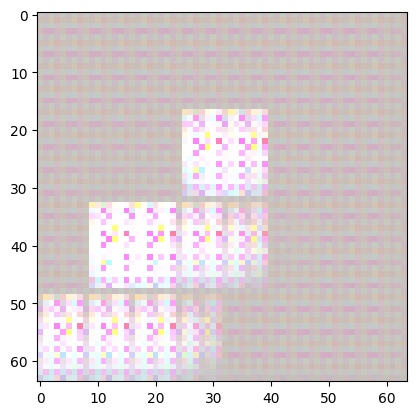

In [26]:
#Génération d'une image à partir d'un vecteur latent aléatoire
with torch.no_grad():
    x = gen(z_fixed)

img = (x[0] + 1) / 2
plt.imshow(img.permute(1, 2, 0))
plt.show()